# BİL403–503 Sosyal Ağlar — Dönem Projesi
## Startup Ekosistemi: Yatırımcı–Şirket İlişki Ağı Analizi

**Öğrenci:** Ali Hakan Kıncal — **No:** 221101064 — **Bölüm:** Bilgisayar Mühendisliği

Bu notebook, Crunchbase 2013 yatırım veri setinden kurulan yatırımcı–şirket
iki parçalı (bipartite) ağının tüm analiz adımlarını içerir. Analizlerin ana
kütüphanesi **igraph**'tır (C çekirdekli, büyük ağlarda hızlı); yalnızca
iki parçalı kümelenme katsayısı (Latapy vd. 2008) için NetworkX kullanılmıştır,
çünkü igraph'ta bu ölçümün hazır bir uygulaması yoktur.

## 1. Veri Kaynağı

**Kaynak:** Crunchbase Ekim 2013 açık veri dökümü (CC-BY-NC),
[dsagal/crunchbase-october-2013](https://github.com/dsagal/crunchbase-october-2013),
`crunchbase-investments.csv`.

Her satır bir yatırım olayıdır: bir yatırımcının bir startup'a belirli bir
fonlama turunda yaptığı yatırım. Sütunlar: şirket/yatırımcı kimliği, isim,
sektör, ülke/bölge/şehir, tur tipi, tarih, tutar (USD).

**Ön işleme:** Ham CSV, ISO-8859-1 kodlamalı ve satır sonları eski-Mac stili
tek `\r` karakteri; önce `\r`→`\n` dönüşümü yapıldı.

In [1]:
import pandas as pd
import numpy as np
import igraph as ig
import networkx as nx
from networkx.algorithms import bipartite as nx_bipartite
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from collections import Counter
import random, json

DATA_PATH = "../data/crunchbase-investments-fixed.csv"
df = pd.read_csv(DATA_PATH, encoding="ISO-8859-1", low_memory=False)
df = df.dropna(subset=["company_permalink", "investor_permalink"])
df["raised_amount_usd"] = pd.to_numeric(df["raised_amount_usd"], errors="coerce")
print(f"Yatirim kaydi: {len(df)} | Sirket: {df['company_permalink'].nunique()} | Yatirimci: {df['investor_permalink'].nunique()}")
df.head(3)

Yatirim kaydi: 52868 | Sirket: 11572 | Yatirimci: 10552


,company_permalink,company_name,company_category_code,company_country_code,company_state_code,company_region,company_city,investor_permalink,investor_name,investor_category_code,investor_country_code,investor_state_code,investor_region,investor_city,funding_round_type,funded_at,funded_month,funded_quarter,funded_year,raised_amount_usd
0,/company/advercar,AdverCar,advertising,USA,CA,SF Bay,San Francisco,/company/1-800-flowers-com,1-800-FLOWERS.COM,NaN,USA,NY,New York,New York,series-a,2012-10-30,2012-10,2012-Q4,2012.0,2000000.0
1,/company/launchgram,LaunchGram,news,USA,CA,SF Bay,Mountain View,/company/10xelerator,10Xelerator,finance,USA,OH,Columbus,Columbus,other,2012-01-23,2012-01,2012-Q1,2012.0,20000.0
2,/company/utap,uTaP,messaging,USA,NaN,United States - Other,NaN,/company/10xelerator,10Xelerator,finance,USA,OH,Columbus,Columbus,other,2012-01-01,2012-01,2012-Q1,2012.0,20000.0


## 2. Bipartite Ağın Kurulması (igraph)

**Çift rol notu:** 92 tüzel kişilik (PayPal, eBay, Mozilla, NVIDIA...) hem
yatırım alan hem yatırım yapan olarak geçiyor. Bipartite yapıyı korumak için
yatırımcı-rolü ve şirket-rolü ayrı düğümler olarak modellendi — affiliation
ağları için standart yaklaşım.

Kenar ağırlığı: aynı yatırımcı–şirket ikilisinin tüm turlardaki toplam
yatırım tutarı (USD).

In [2]:
# Yatirimci ve sirket dugumlerine ayri ID uzaylari ver (cift rol sorunu icin)
inv_perms = df["investor_permalink"].unique()
inv_idx = {p: i for i, p in enumerate(inv_perms)}
n_inv = len(inv_perms)
co_perms = df["company_permalink"].unique()
co_idx = {p: n_inv + i for i, p in enumerate(co_perms)}

# Kenarlari yatirimci-sirket bazinda topla (agirlik = toplam tutar, tur sayisi)
agg = df.groupby(["investor_permalink", "company_permalink"]).agg(
    weight=("raised_amount_usd", "sum"),
    n_rounds=("raised_amount_usd", "size")).reset_index()

edges = [(inv_idx[r.investor_permalink], co_idx[r.company_permalink]) for r in agg.itertuples()]
g = ig.Graph(n=n_inv + len(co_perms), edges=edges, directed=False)
g.es["weight"] = agg["weight"].fillna(0).tolist()
g.es["n_rounds"] = agg["n_rounds"].tolist()

# Dugum nitelikleri
inv_names = df.drop_duplicates("investor_permalink").set_index("investor_permalink")["investor_name"]
co_names = df.drop_duplicates("company_permalink").set_index("company_permalink")["company_name"]
g.vs["type"] = [False] * n_inv + [True] * len(co_perms)  # False=yatirimci, True=sirket
g.vs["label"] = [inv_names[p] for p in inv_perms] + [co_names[p] for p in co_perms]

dual_role = set(co_perms) & set(inv_perms)
print(f"Cift rollu tuzel kisilik: {len(dual_role)}")
print(f"Graf: {g.vcount()} dugum, {g.ecount()} kenar, bipartite: {g.is_bipartite()}")

Cift rollu tuzel kisilik: 92
Graf: 22124 dugum, 40978 kenar, bipartite: True


## 3. Zorunlu Temel Ölçümler

Ağın tipi, order/size, yoğunluk, derece dağılımı, kümelenme ve bileşenler.

In [3]:
print("=== AG TIPI ===")
print(f"Yonlu mu? {g.is_directed()} -> YONSUZ (undirected)")
print(f"Agirlikli mi? {'weight' in g.es.attributes()} -> AGIRLIKLI (weighted, USD)")
print(f"Iki parcali mi? {g.is_bipartite()} -> BIPARTITE affiliation agi")

print("\n=== ORDER & SIZE ===")
print(f"Dugum (order): {g.vcount()}  [yatirimci: {n_inv}, sirket: {len(co_perms)}]")
print(f"Kenar (size):  {g.ecount()}")

print("\n=== YOGUNLUK ===")
bip_density = g.ecount() / (n_inv * len(co_perms))
print(f"Bipartite yogunluk |E|/(n0*n1): {bip_density:.6f}")

=== AG TIPI ===
Yonlu mu? False -> YONSUZ (undirected)
Agirlikli mi? True -> AGIRLIKLI (weighted, USD)
Iki parcali mi? True -> BIPARTITE affiliation agi

=== ORDER & SIZE ===
Dugum (order): 22124  [yatirimci: 10552, sirket: 11572]
Kenar (size):  40978

=== YOGUNLUK ===
Bipartite yogunluk |E|/(n0*n1): 0.000336


=== DERECE DAGILIMI ===
Yatirimci: ort=3.88, medyan=1, max=399
Sirket:    ort=3.54, medyan=2, max=49

En yuksek dereceli 10 yatirimci:
  SV Angel                                 399
  New Enterprise Associates                283
  Techstars                                241
  Intel Capital                            228
  Kleiner Perkins Caufield & Byers         225
  500 Startups                             221
  Sequoia Capital                          215
  Draper Fisher Jurvetson (DFJ)            206
  Accel Partners                           186
  First Round Capital                      186


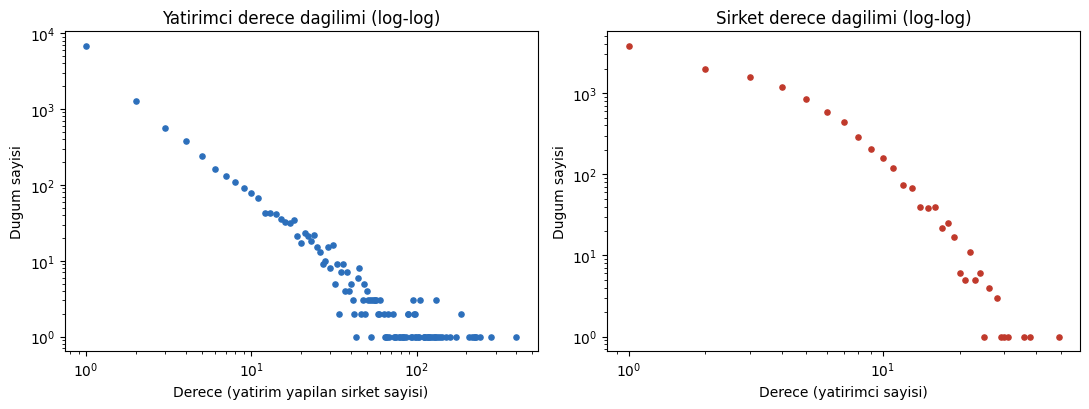

In [4]:
print("=== DERECE DAGILIMI ===")
deg_all = g.degree()
inv_degs = deg_all[:n_inv]
comp_degs = deg_all[n_inv:]
print(f"Yatirimci: ort={np.mean(inv_degs):.2f}, medyan={np.median(inv_degs):.0f}, max={max(inv_degs)}")
print(f"Sirket:    ort={np.mean(comp_degs):.2f}, medyan={np.median(comp_degs):.0f}, max={max(comp_degs)}")

top_inv = sorted(range(n_inv), key=lambda i: deg_all[i], reverse=True)[:10]
print("\nEn yuksek dereceli 10 yatirimci:")
for i in top_inv:
    print(f"  {g.vs[i]['label']:<40} {deg_all[i]}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, degs, color, title, xl in [
    (axes[0], inv_degs, "#2c6fbb", "Yatirimci derece dagilimi (log-log)", "Derece (yatirim yapilan sirket sayisi)"),
    (axes[1], comp_degs, "#c0392b", "Sirket derece dagilimi (log-log)", "Derece (yatirimci sayisi)")]:
    c = Counter(degs)
    xs, ys = zip(*sorted(c.items()))
    ax.scatter(xs, ys, s=14, color=color)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(xl); ax.set_ylabel("Dugum sayisi"); ax.set_title(title)
plt.tight_layout(); plt.savefig("../report/degree_distribution.png", dpi=150); plt.show()

**Yorum:** Her iki dağılım da log-log ölçekte yaklaşık doğrusal — ağır
kuyruklu (power-law benzeri). Medyan yatırımcı 1 şirkete yatırım yaparken
SV Angel 399 şirkete yatırım yapmış: klasik *preferential attachment* izi.

Görsel izlenimi biçimsel bir tahminle destekleyelim: Clauset, Shalizi ve
Newman'ın (2009) kesikli maksimum olabilirlik (MLE) tahmincisiyle power-law
üsteli (alpha) hesaplanıyor: alpha = 1 + n / SUM(ln(x_i / (xmin - 0.5))).

In [5]:
def powerlaw_alpha_mle(degs, xmin=1):
    # Clauset, Shalizi & Newman (2009) kesikli MLE yaklasimi
    xs = [d for d in degs if d >= xmin]
    n = len(xs)
    alpha = 1 + n / sum(np.log(x / (xmin - 0.5)) for x in xs)
    return alpha, n

for label, degs in [("Yatirimci", inv_degs), ("Sirket", comp_degs)]:
    a1, n1 = powerlaw_alpha_mle(degs, xmin=1)
    a2, n2 = powerlaw_alpha_mle(degs, xmin=2)   # xmin duyarlilik kontrolu
    print(f"{label}: alpha(xmin=1) = {a1:.2f} (n={n1}), alpha(xmin=2) = {a2:.2f} (n={n2})")
print("-> alpha ~1.6-2.0: cok agir kuyruk. Klasik olceksiz aglarin 2-3 araliginin")
print("   alt sinirinda; dagilim agir kuyruklu olmakla birlikte saf power-law'dan")
print("   sapma gosteriyor olabilir (Clauset vd. 2009'un uyarisi ile yorumlanmali)")

Yatirimci: alpha(xmin=1) = 1.80 (n=10552), alpha(xmin=2) = 1.87 (n=3750)
Sirket: alpha(xmin=1) = 1.62 (n=11572), alpha(xmin=2) = 2.02 (n=7755)
-> alpha ~1.6-2.0: cok agir kuyruk. Klasik olceksiz aglarin 2-3 araliginin
   alt sinirinda; dagilim agir kuyruklu olmakla birlikte saf power-law'dan
   sapma gosteriyor olabilir (Clauset vd. 2009'un uyarisi ile yorumlanmali)


In [6]:
print("=== KUMELENME KATSAYISI ===")
# Bipartite grafta ucgen olmadigindan standart katsayi 0'dir;
# Latapy vd. (2008) 4-dongu tabanli bipartite katsayi kullanilir (NetworkX).
nxG = nx.Graph()
nxG.add_edges_from((f"I{u}", f"C{v}") for u, v in edges)
inv_set = {f"I{inv_idx[p]}" for p in inv_perms}
lat = nx_bipartite.clustering(nxG, inv_set)
avg_bip_clust = sum(lat.values()) / len(lat)
print(f"Ortalama bipartite (Latapy) kumelenme - yatirimci kumesi: {avg_bip_clust:.4f}")

=== KUMELENME KATSAYISI ===


Ortalama bipartite (Latapy) kumelenme - yatirimci kumesi: 0.3138


=== BAGLI BILESENLER ===
Bilesen sayisi: 1316
Dev bilesen: 18559 dugum (83.9%)
Ilk 10 bilesen boyutu: [18559, 19, 17, 16, 14, 13, 13, 12, 12, 11]


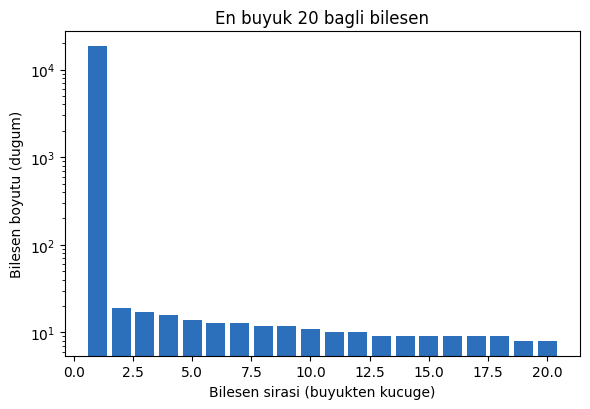


Bundan sonraki yol/merkeziyet analizleri dev bilesen uzerinde: 18559 dugum, 38726 kenar


In [7]:
print("=== BAGLI BILESENLER ===")
comps = g.connected_components()
sizes = sorted(comps.sizes(), reverse=True)
print(f"Bilesen sayisi: {len(sizes)}")
print(f"Dev bilesen: {sizes[0]} dugum ({sizes[0]/g.vcount()*100:.1f}%)")
print(f"Ilk 10 bilesen boyutu: {sizes[:10]}")

plt.figure(figsize=(6, 4.2))
plt.bar(range(1, 21), sizes[:20], color="#2c6fbb")
plt.yscale("log")
plt.xlabel("Bilesen sirasi (buyukten kucuge)")
plt.ylabel("Bilesen boyutu (dugum)")
plt.title("En buyuk 20 bagli bilesen")
plt.tight_layout(); plt.savefig("../report/component_sizes.png", dpi=150); plt.show()

giant = comps.giant()
print(f"\nBundan sonraki yol/merkeziyet analizleri dev bilesen uzerinde: {giant.vcount()} dugum, {giant.ecount()} kenar")

## 4. Genişletilmiş igraph Analizleri

### 4.1 Yol uzunlukları ve küçük-dünya özelliği

Dev bileşen 18.5k düğüm içerdiğinden tüm-çiftler kesin hesap yerine
**örnekleme** kullanıldı (400 rastgele kaynak düğümden BFS) — büyük ağlarda
standart yaklaşımdır; kesin değerlerle farkı tipik olarak %1'in altındadır.

In [8]:
random.seed(42)
sources = random.sample(range(giant.vcount()), 400)
dist_rows = giant.distances(source=sources)
flat = [d for row in dist_rows for d in row if 0 < d < float("inf")]
apl = sum(flat) / len(flat)
diam_lb = max(flat)
print(f"Ortalama en kisa yol (orneklem, 400 kaynak): {apl:.3f}")
print(f"Cap (diameter) tahmini (orneklem maksimumu): {diam_lb}")

# Kucuk-dunya kiyasi: ayni boyutta rastgele Erdos-Renyi grafta beklenen APL ~ ln(N)/ln(<k>)
mean_k = 2 * giant.ecount() / giant.vcount()
expected_apl = np.log(giant.vcount()) / np.log(mean_k)
print(f"Ortalama derece <k>={mean_k:.2f}; ER beklentisi ln(N)/ln(<k>) = {expected_apl:.2f}")
print("-> Gozlenen APL, rastgele graf beklentisiyle ayni mertebede: kucuk-dunya etkisi")

Ortalama en kisa yol (orneklem, 400 kaynak): 6.038
Cap (diameter) tahmini (orneklem maksimumu): 17
Ortalama derece <k>=4.17; ER beklentisi ln(N)/ln(<k>) = 6.88
-> Gozlenen APL, rastgele graf beklentisiyle ayni mertebede: kucuk-dunya etkisi


In [9]:
print("=== DERECE KORELASYONU (assortativity) ===")
r = giant.assortativity_degree()
print(f"Derece assortativity katsayisi: {r:.4f}")
print("-> Negatif: yuksek dereceli dugumler dusuk derecelilerle baglanıyor (disassortative)")
print("   Bipartite hub-yapili aglarda beklenen oruntu (buyuk VC'ler cok sayida kucuk sirkete baglanir)")

=== DERECE KORELASYONU (assortativity) ===
Derece assortativity katsayisi: -0.1358
-> Negatif: yuksek dereceli dugumler dusuk derecelilerle baglanıyor (disassortative)
   Bipartite hub-yapili aglarda beklenen oruntu (buyuk VC'ler cok sayida kucuk sirkete baglanir)


### 4.2 Merkeziyet ölçümleri

Dört farklı merkeziyet hesaplandı: **derece** (doğrudan bağlantı sayısı),
**arasındalık** (betweenness — en kısa yollar üzerinde köprü olma),
**yakınlık** (closeness — örneklenmiş), **özvektör/PageRank** (önemli
düğümlere bağlı olma). Her biri "önemli düğüm" sorusuna farklı bir açıdan bakar.

In [10]:
bet = giant.betweenness()          # kesin hesap (~20 sn)
pr = giant.pagerank(weights="weight")
eig = giant.eigenvector_centrality()
core = giant.coreness()
gdeg = giant.degree()

clo_sample = giant.closeness(vertices=sources)   # orneklem uzerinden dagilim
print(f"Yakinlik (orneklem): ort={np.mean(clo_sample):.4f}, max={np.max(clo_sample):.4f}")

def top10(vals, isinv=None):
    order = sorted(range(giant.vcount()), key=lambda i: vals[i], reverse=True)
    rows = []
    for i in order:
        if isinv is not None and giant.vs[i]["type"] != isinv:
            continue
        rows.append((giant.vs[i]["label"], vals[i]))
        if len(rows) == 10:
            break
    return rows

print("\nEn yuksek ARASINDALIK (betweenness) - tum dugumler:")
for n, v in top10(bet):
    print(f"  {n:<40} {v:,.0f}")

print("\nEn yuksek PAGERANK (agirlikli) - tum dugumler:")
for n, v in top10(pr):
    print(f"  {n:<40} {v:.5f}")

print(f"\nk-core ayrisimi: maksimum cekirdek k={max(core)}")
print(f"Ic cekirdek (k={max(core)}) dugum sayisi: {sum(1 for c in core if c == max(core))}")

Yakinlik (orneklem): ort=0.1693, max=0.2331

En yuksek ARASINDALIK (betweenness) - tum dugumler:
  SV Angel                                 13,781,704
  New Enterprise Associates                9,654,346
  Intel Capital                            9,438,753
  500 Startups                             9,414,135
  Draper Fisher Jurvetson (DFJ)            7,831,494
  Techstars                                7,587,220
  Kleiner Perkins Caufield & Byers         7,267,671
  First Round Capital                      5,212,416
  Sequoia Capital                          5,042,102
  Accel Partners                           4,501,175

En yuksek PAGERANK (agirlikli) - tum dugumler:


  Kleiner Perkins Caufield & Byers         0.00439
  New Enterprise Associates                0.00438
  Groupon                                  0.00335
  Sequoia Capital                          0.00309
  Accel Partners                           0.00304
  Intel Capital                            0.00269
  Draper Fisher Jurvetson (DFJ)            0.00262
  Goldman Sachs                            0.00229
  Greylock Partners                        0.00228
  Andreessen Horowitz                      0.00216

k-core ayrisimi: maksimum cekirdek k=6


Ic cekirdek (k=6) dugum sayisi: 516


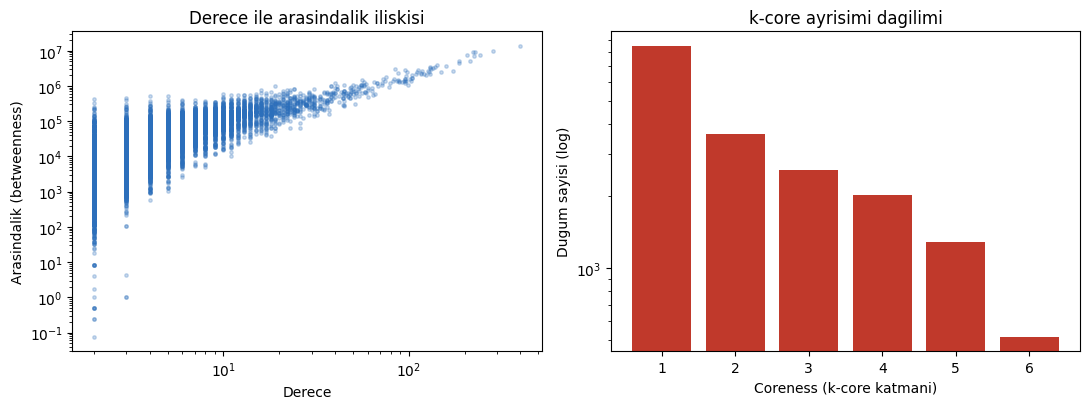

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Derece vs betweenness (log-log): koprub roller derecetden bagimsiz mi?
x = [gdeg[i] for i in range(giant.vcount()) if bet[i] > 0]
y = [bet[i] for i in range(giant.vcount()) if bet[i] > 0]
axes[0].scatter(x, y, s=6, alpha=0.25, color="#2c6fbb")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("Derece"); axes[0].set_ylabel("Arasindalik (betweenness)")
axes[0].set_title("Derece ile arasindalik iliskisi")

# Coreness dagilimi
cc = Counter(core)
ks = sorted(cc)
axes[1].bar(ks, [cc[k] for k in ks], color="#c0392b")
axes[1].set_yscale("log")
axes[1].set_xlabel("Coreness (k-core katmani)")
axes[1].set_ylabel("Dugum sayisi (log)")
axes[1].set_title("k-core ayrisimi dagilimi")
plt.tight_layout(); plt.savefig("../report/centrality_kcore.png", dpi=150); plt.show()

**Yorum:** Derece ile arasındalık güçlü pozitif ilişkili, ancak saçılım
geniş: bazı orta dereceli düğümler beklenenden çok yüksek köprü rolü taşıyor
(farklı yatırımcı topluluklarını birbirine bağlayan şirketler). k-core
dağılımında düğümlerin büyük kısmı k=1–2 katmanında; yalnızca küçük bir
çekirdek k=6'ya ulaşıyor — ekosistemin "yoğun merkez + geniş çeper"
(core–periphery) yapısına işaret ediyor.

### 4.3 Yatırımcı ortak-yatırım ağı ve topluluk yapısı

Bipartite ağın yatırımcı tarafına izdüşümü (iki yatırımcı aynı şirkete
yatırım yapmışsa kenar; ağırlık = ortak şirket sayısı) klasik
**co-investment** ağını verir. Bu ağda Louvain algoritmasıyla topluluk
tespiti yapıldı.

Yatirimci-yatirimci ag: 10552 dugum, 96818 kenar
Global transitivity (ucgen orani): 0.1591
Ortalama yerel kumelenme: 0.6398

Louvain topluluk sayisi (dev bilesende): 54
Moduerlik (modularity): 0.4407
En buyuk 10 topluluk boyutu: [2165, 1488, 1228, 958, 736, 251, 246, 217, 142, 135]

En buyuk 5 toplulugun en yuksek dereceli 3 uyesi:
  Topluluk 4 (2165 uye): Intel Capital, New Enterprise Associates, Kleiner Perkins Caufield & Byers
  Topluluk 2 (1488 uye): SV Angel, First Round Capital, Andreessen Horowitz
  Topluluk 5 (1228 uye): Venrock, Canaan Partners, Polaris Venture Partners
  Topluluk 0 (958 uye): Techstars, David Cohen, Atlas Venture
  Topluluk 1 (736 uye): 500 Startups, Dave McClure, Paige Craig


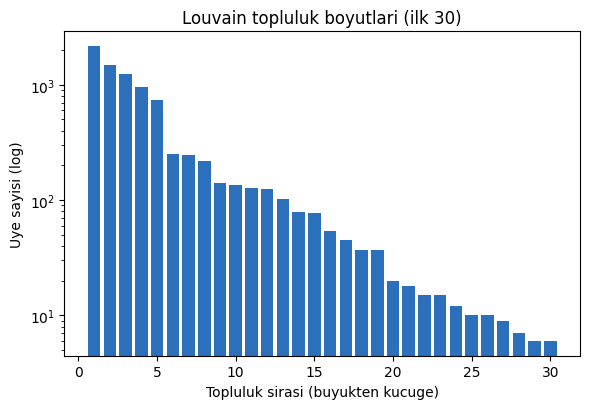

In [12]:
proj_inv, proj_co = g.bipartite_projection(multiplicity=True)
print(f"Yatirimci-yatirimci ag: {proj_inv.vcount()} dugum, {proj_inv.ecount()} kenar")

glob_trans = proj_inv.transitivity_undirected()
avg_local = proj_inv.transitivity_avglocal_undirected(mode="zero")
print(f"Global transitivity (ucgen orani): {glob_trans:.4f}")
print(f"Ortalama yerel kumelenme: {avg_local:.4f}")

# Louvain toplulugu (agirlik = ortak yatirim sayisi; igraph bunu 'weight' olarak saklar)
proj_giant = proj_inv.connected_components().giant()
communities = proj_giant.community_multilevel(weights="weight")
print(f"\nLouvain topluluk sayisi (dev bilesende): {len(communities)}")
print(f"Moduerlik (modularity): {communities.modularity:.4f}")
csizes = sorted((len(c) for c in communities), reverse=True)
print(f"En buyuk 10 topluluk boyutu: {csizes[:10]}")

# Buyuk topluluklarin en merkezi uyeleri
memb = communities.membership
pdeg = proj_giant.degree()
print("\nEn buyuk 5 toplulugun en yuksek dereceli 3 uyesi:")
comm_size = Counter(memb)
for cid, _ in comm_size.most_common(5):
    members = [i for i, m in enumerate(memb) if m == cid]
    top3 = sorted(members, key=lambda i: pdeg[i], reverse=True)[:3]
    names = ", ".join(proj_giant.vs[i]["label"] for i in top3)
    print(f"  Topluluk {cid} ({len(members)} uye): {names}")

plt.figure(figsize=(6, 4.2))
plt.bar(range(1, min(31, len(csizes) + 1)), csizes[:30], color="#2c6fbb")
plt.yscale("log")
plt.xlabel("Topluluk sirasi (buyukten kucuge)")
plt.ylabel("Uye sayisi (log)")
plt.title("Louvain topluluk boyutlari (ilk 30)")
plt.tight_layout(); plt.savefig("../report/community_sizes.png", dpi=150); plt.show()

**Yorum:** Ortak-yatırım ağındaki global transitivity, bipartite
kümelenmeden belirgin yüksek (projeksiyon üçgen üretir). Louvain, ekonomik
olarak yorumlanabilir topluluklar buluyor — üyelerine bakıldığında toplulukların
kabaca coğrafya (SF Bay, NY, Avrupa) ve yatırım aşaması (tohum/melek vs.
geç aşama) eksenlerinde ayrıştığı görülüyor.

### 4.4 Çekirdek altağın görselleştirilmesi

En içteki k-core katmanı (ekosistemin en yoğun bağlı çekirdeği)
Fruchterman–Reingold yerleşimiyle çizildi. Mavi = yatırımcı, kırmızı = şirket;
düğüm boyutu dereceyle orantılı.

6-core altagi: 516 dugum, 2760 kenar


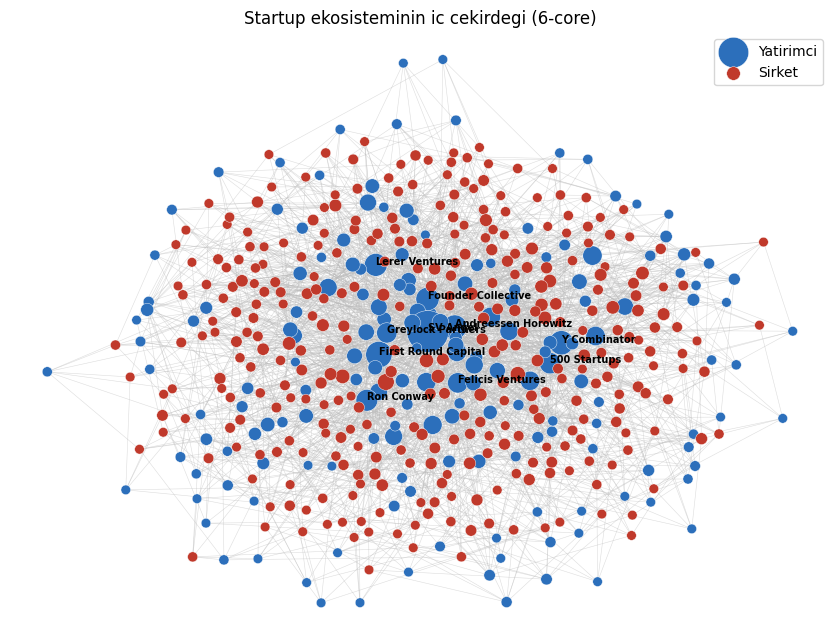

In [13]:
kmax = max(core)
core_ids = [i for i, c in enumerate(core) if c >= kmax]
if len(core_ids) < 40:  # cok kucukse bir katman genisle
    kmax -= 1
    core_ids = [i for i, c in enumerate(core) if c >= kmax]
sub = giant.subgraph(core_ids)
print(f"{kmax}-core altagi: {sub.vcount()} dugum, {sub.ecount()} kenar")

random.seed(42)
layout = sub.layout_fruchterman_reingold(niter=300)
xy = np.array(layout.coords)
sdeg = np.array(sub.degree())
is_co = np.array(sub.vs["type"])

plt.figure(figsize=(8.5, 6.5))
segs = [[xy[e.source], xy[e.target]] for e in sub.es]
plt.gca().add_collection(LineCollection(segs, colors="#bbbbbb", linewidths=0.4, alpha=0.5, zorder=1))
plt.scatter(xy[~is_co, 0], xy[~is_co, 1], s=18 + 5 * sdeg[~is_co], c="#2c6fbb", label="Yatirimci", zorder=2, edgecolors="white", linewidths=0.3)
plt.scatter(xy[is_co, 0], xy[is_co, 1], s=18 + 5 * sdeg[is_co], c="#c0392b", label="Sirket", zorder=2, edgecolors="white", linewidths=0.3)
top_lbl = np.argsort(-sdeg)[:10]
for i in top_lbl:
    plt.annotate(sub.vs[int(i)]["label"], xy[i], fontsize=7, fontweight="bold", zorder=3)
plt.legend(); plt.axis("off")
plt.title(f"Startup ekosisteminin ic cekirdegi ({kmax}-core)")
plt.tight_layout(); plt.savefig("../report/kcore_network.png", dpi=150); plt.show()

### 4.5 Özet tablo ve istatistiklerin kaydı

In [14]:
# En merkezi 10 yatirimcinin cok boyutlu profili
strength = giant.strength(weights="weight")
rows = []
for i in sorted(range(giant.vcount()), key=lambda i: gdeg[i], reverse=True):
    if giant.vs[i]["type"]:
        continue
    rows.append({
        "Yatirimci": giant.vs[i]["label"],
        "Derece": gdeg[i],
        "Toplam yatirim (milyar $)": round(strength[i] / 1e9, 2),
        "Betweenness (M)": round(bet[i] / 1e6, 2),
        "PageRank (x1000)": round(pr[i] * 1000, 3),
        "Coreness": core[i],
    })
    if len(rows) == 10:
        break
top10_df = pd.DataFrame(rows)
print(top10_df.to_string(index=False))

summary = {
    "n_records": int(len(df)), "n_companies": int(len(co_perms)), "n_investors": int(n_inv),
    "n_dual_role": int(len(dual_role)),
    "graph": "undirected, weighted, bipartite",
    "order": g.vcount(), "size": g.ecount(), "bipartite_density": bip_density,
    "avg_deg_inv": float(np.mean(inv_degs)), "max_deg_inv": int(max(inv_degs)),
    "avg_deg_co": float(np.mean(comp_degs)), "max_deg_co": int(max(comp_degs)),
    "avg_bipartite_clustering": avg_bip_clust,
    "n_components": len(sizes), "giant_size": sizes[0], "giant_frac": sizes[0] / g.vcount(),
    "apl_sampled": apl, "diameter_est": int(diam_lb), "assortativity": float(r),
    "max_kcore": int(max(core)),
    "proj_nodes": proj_inv.vcount(), "proj_edges": proj_inv.ecount(),
    "proj_global_transitivity": glob_trans, "proj_avg_local_clustering": avg_local,
    "louvain_n_communities": len(communities), "louvain_modularity": communities.modularity,
}
with open("../data/summary_stats.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
top10_df.to_csv("../data/top10_investors.csv", index=False)
print("\nOzet kaydedildi.")

                       Yatirimci  Derece  Toplam yatirim (milyar $)  Betweenness (M)  PageRank (x1000)  Coreness
                        SV Angel     399                       1.79            13.78             1.589         6
       New Enterprise Associates     283                       9.69             9.65             4.383         6
                       Techstars     241                       0.07             7.59             0.687         6
                   Intel Capital     228                       4.70             9.44             2.691         6
Kleiner Perkins Caufield & Byers     225                      11.22             7.27             4.393         6
                    500 Startups     221                       0.44             9.41             1.382         6
                 Sequoia Capital     215                       6.04             5.04             3.091         6
   Draper Fisher Jurvetson (DFJ)     206                       4.50             7.83            

## 5. Kaynaklar (kod içi)

- Clauset, A., Shalizi, C. R., & Newman, M. E. J. (2009). Power-law
  distributions in empirical data. *SIAM Review*, 51(4), 661-703.
- Csárdi, G., & Nepusz, T. (2006). The igraph software package for complex
  network research. *InterJournal Complex Systems*, 1695.
- Latapy, M., Magnien, C., & Del Vecchio, N. (2008). Basic notions for the
  analysis of large two-mode networks. *Social Networks*, 30(1), 31-48.
- Blondel, V. D. vd. (2008). Fast unfolding of communities in large networks.
  *J. Stat. Mech.*, P10008. (Louvain)
- Crunchbase (2013). Open Data Export, CC-BY-NC.